<a href="https://colab.research.google.com/github/nehasmane2003-stack/MACHINE-LEARNING-Clg/blob/main/ASS_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing k-Nearest Neighbors (KNN)
First, let's determine the best 'k' value for our KNN classifier. We'll iterate through a range of 'k' values (from 1 to 20), train a KNN model for each 'k', and evaluate its accuracy on the test set. The 'k' that yields the highest accuracy will be selected as the optimal 'k'.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# List to store accuracies for different k values
accuracies = []

# Define a range of k values to test
k_values = range(1, 21)

# Iterate through each k value
for k in k_values:
    # Initialize KNN classifier with the current k
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model using the scaled training data
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the scaled test data
    y_pred_k = knn.predict(X_test_scaled)

    # Calculate the accuracy of the predictions
    accuracy = accuracy_score(y_test, y_pred_k)

    # Store the accuracy
    accuracies.append(accuracy)

# Find the index of the maximum accuracy to determine the best k
best_k_index = np.argmax(accuracies)
best_k = k_values[best_k_index]

# Print the accuracies and the optimal k value
print(f"Accuracies for k values (1-20): {accuracies}")
print(f"The optimal k for the KNN classifier is: {best_k} with an accuracy of {accuracies[best_k_index]:.4f}")

Accuracies for k values (1-20): [0.92, 0.895, 0.93, 0.925, 0.93, 0.925, 0.93, 0.925, 0.92, 0.92, 0.92, 0.92, 0.935, 0.915, 0.93, 0.935, 0.93, 0.925, 0.915, 0.92]
The optimal k for the KNN classifier is: 13 with an accuracy of 0.9350


## Train KNN with Best k

Now that we've found the optimal 'k' value (which is `best_k`), we'll train the final k-Nearest Neighbors classifier using this value. We'll then evaluate its performance on the test set using various metrics like accuracy, classification report, and confusion matrix to get a comprehensive understanding of its effectiveness.

## Visualize Decision Boundary

To visualize the decision boundary, we'll first reduce the dimensionality of our `X_train_scaled` data to two principal components using PCA. This will allow us to plot the data and the decision boundary in a 2D space. After training a new KNN model on this PCA-transformed data, we'll create a meshgrid to plot the decision boundary along with the training data points.

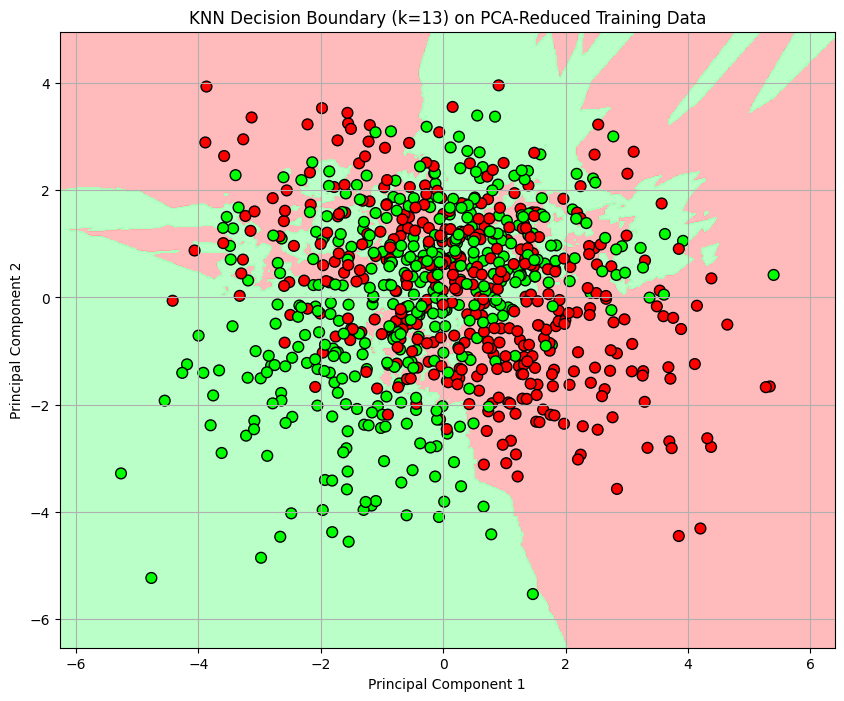

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA on X_train_scaled and transform both X_train_scaled and X_test_scaled
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Re-train KNN model on PCA-reduced data for visualization
knn_pca = KNeighborsClassifier(n_neighbors=best_k)
knn_pca.fit(X_train_pca, y_train)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFBB'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=cmap_bold, s=60, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'KNN Decision Boundary (k={best_k}) on PCA-Reduced Training Data')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate and train the final KNN model with the best_k
final_knn_model = KNeighborsClassifier(n_neighbors=best_k)
final_knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = final_knn_model.predict(X_test_scaled)

# Calculate and print the accuracy score
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final KNN Model Accuracy (k={best_k}): {final_accuracy:.4f}")

# Generate and print the classification report
report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(report)

# Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Final KNN Model Accuracy (k=13): 0.9350

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        99
           1       0.92      0.95      0.94       101

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200


Confusion Matrix:
[[91  8]
 [ 5 96]]
